In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
import pickle
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv("data/final_house_data.csv")

In [29]:
def parse_age(age_str):
    if 'Sıfır' in age_str:
        return 0
    try:
        return int(age_str.split(' ')[0])
    except:
        return 0
df['building_age_num'] = df['building_age'].apply(parse_age)

In [30]:
def parse_rooms(room_str):
    try:
        parts = room_str.split('+')
        return sum([int(p.strip()) for p in parts])
    except:
        return 1
df['total_rooms'] = df['room_count'].apply(parse_rooms)

In [31]:
import re

def convert_floor_to_numeric(floor_str):
    if not isinstance(floor_str, str):
        return 0

    floor_str = floor_str.lower()

    if "bodrum" in floor_str:
        return -1
    elif "giriş" in floor_str or "zemin" in floor_str or "bahçe" in floor_str or "kot" in floor_str:
        return 1
    elif "ara kat" in floor_str:
        return 4
    elif "üst" in floor_str or "çatı" in floor_str:
        return 6
    elif "üzeri" in floor_str:
        return 21

    match = re.search(r"\d+", floor_str)
    if match:
        return int(match.group())
    return 1

df['floor_level_num'] = df['floor_level'].apply(convert_floor_to_numeric)

In [32]:
df["is_furnished"] = df["is_furnished"].fillna("Eşyalı Değil")

In [33]:
df["heating_type"] = df["heating_type"].replace("Merkezi (Pay Öl...", "Merkezi")

In [34]:
rare_classes = ['Doğalgaz Sobası', 'Klima', 'VRV', 'Kat Kaloriferi', 'Isıtma Yok', 'Soba', 'Belirtilmemiş']
df["heating_type"] = df["heating_type"].replace(rare_classes, "Diğer")

In [35]:
df_filtred = df[(df['price'] < 50000000) & (df['gross_sqm'] < 500)].copy()

In [36]:
features_to_drop = ["listing_id", "title", "room_count", "building_age", "city_name", "floor_level"]
df_model = df_filtred.drop(columns=features_to_drop, axis=1)

In [37]:
X = df_model.drop("price", axis=1)
y = df_model["price"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
target_cols = ["district_name", "neighborhood_name"]
ohe_cols = ["heating_type", "is_furnished"]

preprocessor = ColumnTransformer(
    transformers=[
        ("low_cardinality", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ohe_cols),
        ("high_cardinality", TargetEncoder(target_type="continuous", random_state=42), target_cols)
    ],
    remainder="passthrough"
)

In [40]:
y_train_log = np.log1p(y_train)

In [41]:
lgb_model = LGBMRegressor(num_leaves=31, n_estimators=200, max_depth=-1, learning_rate=0.05, n_jobs=-1, verbose=-1, random_state=42)

pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', lgb_model)
    ])
pipeline.fit(X_train, y_train_log)
y_pred_log = pipeline.predict(X_test)

C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [42]:
y_pred_normal = np.expm1(y_pred_log)

In [43]:
r2_score(y_test, y_pred_normal)

0.7696137510573415

In [44]:
with open("house_price_model_log.pkl","wb") as file:
    pickle.dump(pipeline, file)

In [51]:
lgbm_model = pipeline.named_steps['model']
preprocessor = pipeline.named_steps['preprocessor']

importances = lgbm_model.feature_importances_

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'Özellik (Feature)': feature_names,
    'Önem Puanı': importances
}).sort_values(by='Önem Puanı', ascending=False)

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_3924\4285962421.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem Puanı', y='Özellik (Feature)', data=importance_df, palette='magma')
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_3924\4285962421.py:6: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\VICTUS\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


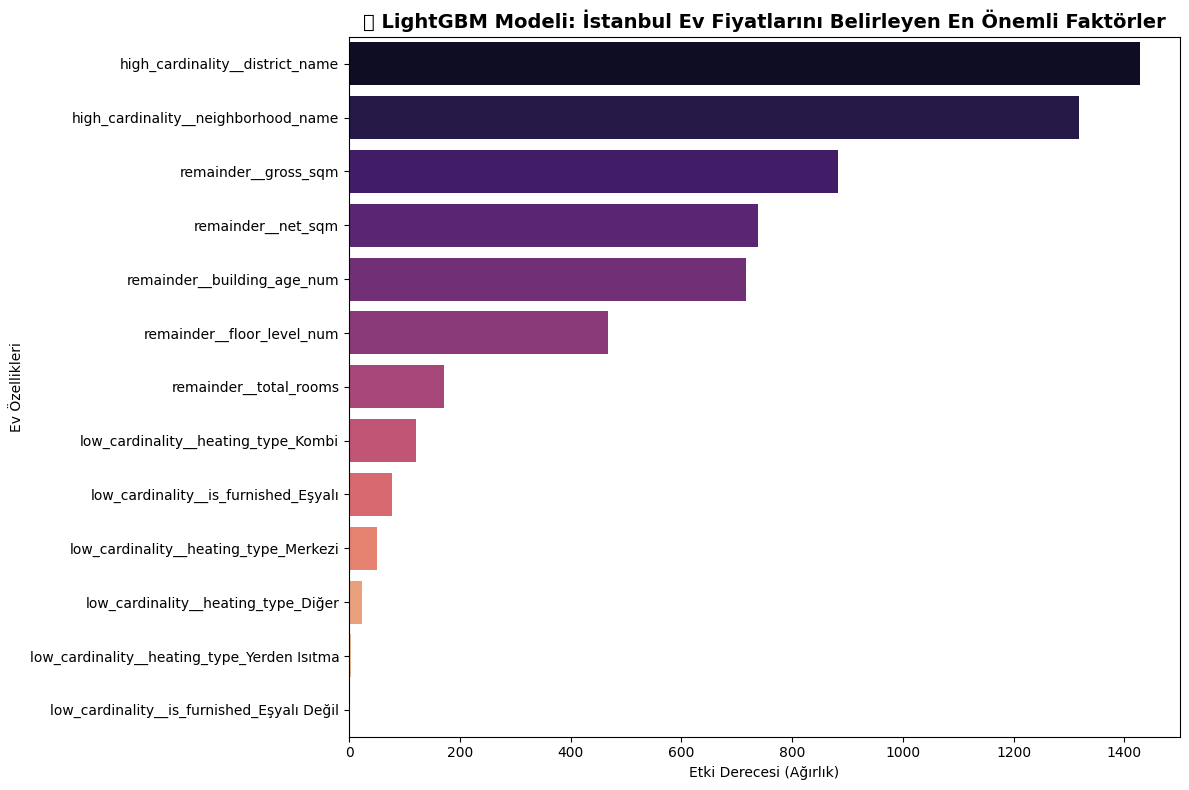

In [52]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Önem Puanı', y='Özellik (Feature)', data=importance_df, palette='magma')
plt.title('✨ LightGBM Modeli: İstanbul Ev Fiyatlarını Belirleyen En Önemli Faktörler', fontsize=14, fontweight='bold')
plt.xlabel('Etki Derecesi (Ağırlık)')
plt.ylabel('Ev Özellikleri')
plt.tight_layout()
plt.show()